**Carbon Emission Model**

In [150]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [151]:
def total_carbon_emission(t):
    return total_energy_consumption_carbon(t) # + total_construction_carbon(t)

def total_construction_carbon(t):
    return ratio_of_HPC_center(t) * (number_of_centers(t) - number_of_centers(t-1)) * (rack_per_center(t) * rack_server_per_rack() * carbon_per_server_built() + carbon_per_building_built(t))

def carbon_energy_ratios(t):
    # g CO2 per kilowatt hour
    return {
        "solar": 52.5,
        "wind" : 11.9,
        "water" : 8.55,
        "nuclear" : 5.65,
        "biomass" : 230,
        "coal" : 1003.5,
        "oil" : 840,
        "natural gas" : 458,
    }

def total_energy_consumption_carbon(t):
    return ratio_of_HPC_center(t) * energy_per_center(t) * number_of_centers(t) * carbon_per_energy(t)

def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : 2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499))), # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^3 = 0.993
        "coal" : 118.059 * t - 228434.206, # r^2 = 0.8686
        "oil" : -43.156 * t + 88039.443, # r^2 = 0.9045
        "natural gas" : 153.993 * t - 304728.245 # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation

def carbon_per_energy(t):
    energy_mix = {
        "solar": energy_ratio(t, "solar"),
        "wind" : energy_ratio(t, "wind"),
        "water" : energy_ratio(t, "water"),
        "nuclear" : energy_ratio(t, "nuclear"),
        "biomass" : energy_ratio(t, "biomass"),
        "coal" : energy_ratio(t, "coal"),
        "oil" : energy_ratio(t, "oil"),
        "natural gas" : energy_ratio(t, "natural gas")
    }
    summation = 0
    for i in energy_mix.keys():
        summation += energy_mix[i] * carbon_energy_ratios(t)[i]
    return summation


def power_per_hpc_rack():
    # kilowatt hour per year
    return 876000

def average_power_usage_effectiveness(t):
    return -0.566751 * math.log(0.00461463 * t - 9.26001,10) + 0.9111179

def ratio_of_HPC_center(t):
    return 1/ (1 + math.pow(math.e, -0.519382 * (t - 2029.669)))

def number_of_centers(t):
    return 18336.937 / (1 + math.pow(math.e, -0.170416 * (t - 2020.504)))

def energy_per_center(t):
    return full_capacity(t) * average_utilization_rate()

def average_utilization_rate():
    return 0.61

def rack_server_per_rack():
    return 42

def rack_per_center(t):
    return area_per_building(t) * rack_space_percentage() / area_per_rack()

def area_per_building(t):
    return total_area(t) / number_of_centers(t)

def total_area(t):
    return 560535928.211 / (1 + math.pow(math.e, -0.161079 * (t - 2028.826)))
def area_per_rack():
    # ft^2
    return 8

def rack_space_percentage():
    return 0.25

def carbon_per_server_built():
    # g CO2
    return 1300000

def carbon_per_building_built(t):
    # g CO2
    return 130640 * area_per_building(t) * 0.0929

def full_capacity(t):
    return rack_per_center(t) * power_per_hpc_rack() * average_power_usage_effectiveness(t)

**Variable Visualization**

In [152]:
print(full_capacity(2024))
print(full_capacity(2024) * ratio_of_HPC_center(2024) * number_of_centers(2024))
print(full_capacity(2024) * ratio_of_HPC_center(2024) * number_of_centers(2024) * average_utilization_rate())
print(full_capacity(2024) * ratio_of_HPC_center(2024) * number_of_centers(2024) * average_utilization_rate() * carbon_per_energy(2024))


626496367.1046854
370332078147.0456
225902567669.6978
108783691906900.9


In [153]:
for year in range(2020,2031):
    print(number_of_centers(year), ratio_of_HPC_center(year), year)


8774.972033913346 0.006548790610374369 2020
9555.726481746671 0.010959565721558226 2021
10330.894649944521 0.01828642592201101 2022
11089.53291809306 0.030361188094062297 2023
11821.620604491225 0.05000296508869051 2024
12518.557417249285 0.08128648601572426 2025
13173.505724007282 0.12947456128490467 2026
13781.557133514822 0.200010208694575 2027
14339.730614819404 0.2959104743777754 2028
14846.831006905786 0.41399690868296846 2029
15303.209043832945 0.5428733193525828 2030


In [154]:
for year in range(2020,2031):
    print(round(area_per_building(year),2), round(rack_per_center(year),2), round(average_power_usage_effectiveness(year),2),ratio_of_HPC_center(year), round(energy_per_center(year) * number_of_centers(year),2),year)

12417.93 388.06 1.6 0.006548790610374369 2906564340809.11 2020
12956.16 404.88 1.58 0.010959565721558226 3265571561177.92 2021
13555.27 423.6 1.56 0.01828642592201101 3654921354614.43 2022
14214.37 444.2 1.55 0.030361188094062297 4073155917936.61 2023
14930.76 466.59 1.53 0.05000296508869051 4517783440822.22 2024
15699.77 490.62 1.52 0.08128648601572426 4985232638650.07 2025
16514.73 516.09 1.51 0.12947456128490467 5470883034145.01 2026
17367.05 542.72 1.49 0.200010208694575 5969182209337.12 2027
18246.54 570.2 1.48 0.2959104743777754 6473850822183.5 2028
19141.82 598.18 1.47 0.41399690868296846 6978163440619.09 2029
20040.87 626.28 1.46 0.5428733193525828 7475280742220.02 2030


6.533549184089485
8.538969857280252
14.02246933278125
8.923136073366061
2.378001636747256
34.51433430654653
2.269949019322065
22.819590589867094
59.60387391573569 50.48387715552679


Text(0, 0.5, 'Percentage of energy type, a_i (%)')

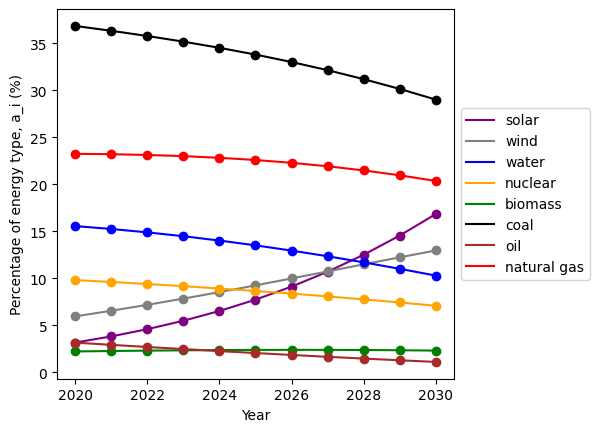

In [155]:
fig,ax = plt.subplots()
years = list(range(2020,2031))

energy_types = ["solar","wind","water","nuclear","biomass","coal","oil","natural gas"]
color = {
    "solar" : "purple",
    "wind" : "gray",
    "water" : "blue",
    "nuclear" : "orange",
    "biomass" : "green",
    "coal" : "black",
    "oil" : "brown",
    "natural gas" : "red"
}
nonrenewable2024 = 0
nonrenewable2030 = 0
for e in energy_types:
    percentiles = [energy_ratio(i,e) * 100 for i in years]
    plt.plot(years, percentiles , c=color[e], label = e)
    plt.plot(years, percentiles , 'o' ,c=color[e])
    if e == "coal" or e == "oil" or e == "natural gas":
        nonrenewable2024 += percentiles[4]
        nonrenewable2030 += percentiles[10]
    print(percentiles[4])
print(nonrenewable2024, nonrenewable2030)
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])


# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# labels and title
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Percentage of energy type, a_i (%)', fontsize=10)


[0.0097, 0.0181, 0.0333, 0.0606, 0.1088, 0.1914, 0.3272, 0.5382, 0.8401, 1.2284, 1.6668]


Text(0, 0.5, 'Carbon Dioxide Emissions (billion metric tons)')

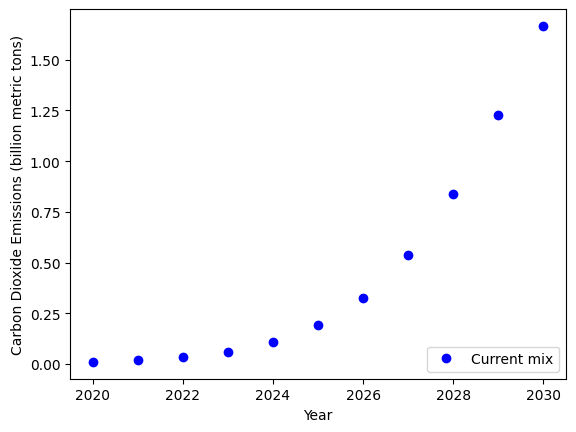

In [156]:
fig,ax = plt.subplots()
years = list(range(2020,2031))
emissions = [(total_carbon_emission(i) / 10**15) for i in years]
print([round(i,4) for i in emissions])
plt.plot(years,emissions ,"o", c="blue", label = "Current mix")
legend = plt.legend(loc = "lower right")
# labels and title
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Carbon Dioxide Emissions (billion metric tons)', fontsize=10)


**Apply Your Model**

**Construction**

[0.0097, 0.0181, 0.0333, 0.0606, 0.1088, 0.1914, 0.3272, 0.5382, 0.8401, 1.2284, 1.6668]
[0.0099, 0.0183, 0.0336, 0.0612, 0.1097, 0.1929, 0.3296, 0.5418, 0.8453, 1.2353, 1.6754]


Text(0.5, 1.0, 'Total carbon emissions from HPC centers')

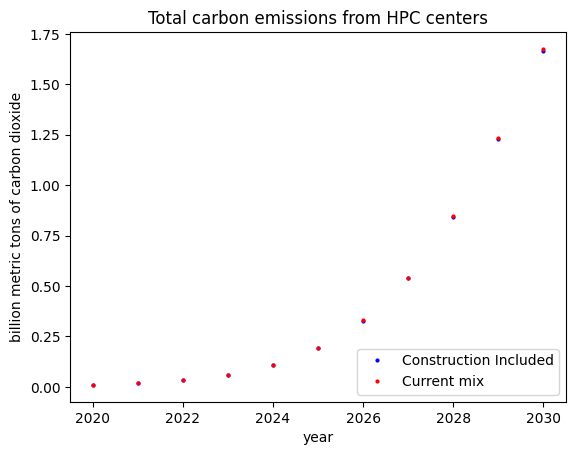

In [157]:
fig,ax = plt.subplots()

years = list(range(2020,2031))
emissions = [(total_carbon_emission(i) / 10**15) for i in years]
print([round(i,4) for i in emissions])
plt.plot(years,emissions ,"o", c="blue", label = "Construction Included", ms = 2)

def total_carbon_emission(t):
    return total_energy_consumption_carbon(t) + total_construction_carbon(t)

years = list(range(2020,2031))
emissions = [(total_carbon_emission(i) / 10**15) for i in years]
print([round(i,4) for i in emissions])
plt.plot(years,emissions ,"o", c="red", label = "Current mix", ms = 2)


legend = plt.legend(loc = "lower right")
# labels and title
ax.set_xlabel('year', fontsize=10)
ax.set_ylabel('billion metric tons of carbon dioxide', fontsize=10)
ax.set_title('Total carbon emissions from HPC centers')


**Increasing demand for energy in other sectors**

Energy bieng used in other sectors will cause our sector to have less energy, leading us to have less energy to push onto HPC servers, leading to a lower percentage at which HPC servers are actually working, meaning the average utilization rate decreases

[0.009857256058699432, 0.018275854754451627, 0.033615147475225204, 0.06117399294045158, 0.1097228996621438, 0.19287861947015256, 0.3296376686642567, 0.5418053360230997, 0.8452707528619301, 1.2352820049627684, 1.6753642112450564]
[0.00809924976233466, 0.015014562059924927, 0.027612940631911633, 0.05024407014217736, 0.09010616833466988, 0.1583728351929815, 0.27062876724274637, 0.44475722304831117, 0.6937787649768506, 1.0137714875407928, 1.3747879452199878]
[0.0053823309406800125, 0.00997438244111093, 0.01833680278315429, 0.0333523712721172, 0.05978940173766471, 0.10504571403735344, 0.17943319231859406, 0.2947737757236383, 0.45965478369990975, 0.6714370515250122, 0.9102609886357913]
[0.004103780906960177, 0.007602533208727871, 0.01397156144256259, 0.02540333650973595, 0.04552268804495639, 0.07995059819941085, 0.1365176276484048, 0.22419332992379204, 0.3494787925107609, 0.5103384933999388, 0.6916600678902869]


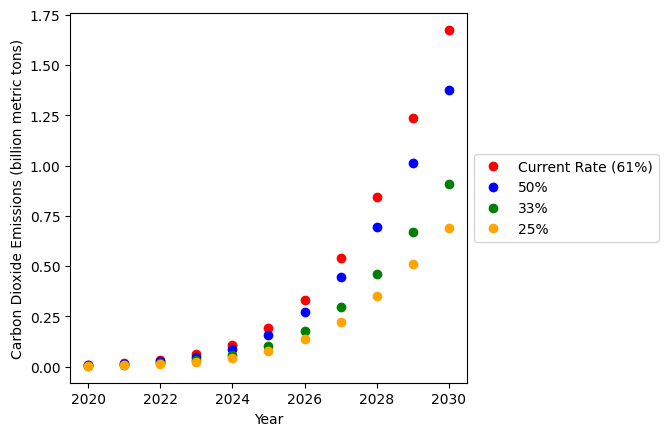

In [158]:
def average_utilization_rate():
    return 0.61
fig,ax = plt.subplots()
years = list(range(2020,2031))
emissions = [(total_carbon_emission(i) / 10**15) for i in years]
print(emissions)
plt.plot(years,emissions , "o", c="red", label = "Current Rate (61%)")

def average_utilization_rate():
    return 0.50
years = list(range(2020,2031))
emissions = [(total_carbon_emission(i) / 10**15) for i in years]
print(emissions)
plt.plot(years,emissions , "o", c="blue", label = "50%")

def average_utilization_rate():
    return 0.33
years = list(range(2020,2031))
emissions = [(total_carbon_emission(i) / 10**15) for i in years]
print(emissions)
plt.plot(years,emissions , "o", c="green", label = "33%")

def average_utilization_rate():
    return 0.25
years = list(range(2020,2031))
emissions = [(total_carbon_emission(i) / 10**15) for i in years]
print(emissions)
plt.plot(years,emissions , "o", c="orange", label = "25%")


box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# labels and title
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Carbon Dioxide Emissions (billion metric tons)', fontsize=10)

def average_utilization_rate():
    return 0.61

[0.009857256058699432, 0.018275854754451627, 0.033615147475225204, 0.06117399294045158, 0.1097228996621438, 0.19287861947015256, 0.3296376686642567, 0.5418053360230997, 0.8452707528619301, 1.2352820049627684, 1.6753642112450564]
[0.0073683062140164485, 0.013597058350116889, 0.024882766114707022, 0.04503405138774859, 0.08029210486871073, 0.14022743043183675, 0.2379678540910304, 0.3881612682777509, 0.6006390626715118, 0.8701899291912356, 1.1695133636692483]
[0.005000548948195169, 0.009195759613458717, 0.016767078058727267, 0.03022966921473133, 0.053680584836860744, 0.09335909769178183, 0.15774917193335478, 0.25618993301718035, 0.394715156871452, 0.5694847234501462, 0.7624691729866673]
[0.0005948493031752262, 0.0011324343361169256, 0.00214170810197096, 0.0040151649041811855, 0.0074366168646335705, 0.013537239835225054, 0.024035614324951673, 0.04119030915797314, 0.06726283755128436, 0.10331819660153331, 0.14792520507158993]
-0.00928968207275549
[0.009834092757797255, 0.018233149607631664, 

Text(0, 0.5, 'Carbon Dioxide Emissions (billion metric tons)')

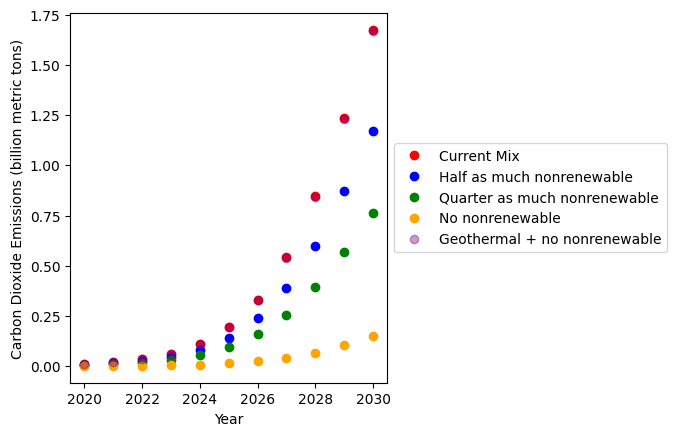

In [159]:
fig,ax = plt.subplots()
years = list(range(2020,2031))
emissions = [(total_carbon_emission(i) / 10**15) for i in years]
t1 = sum(emissions[5:])
print(emissions)
plt.plot(years,emissions , "o", c="red", label = "Current Mix")

def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : 2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499))), # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206) * 0.5, # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443) * 0.5, # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) * 0.5 # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation

years = list(range(2020,2031))
emissions = [(total_carbon_emission(i) / 10**15) for i in years]
print(emissions)
plt.plot(years,emissions , "o", c="blue", label = "Half as much nonrenewable")


def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : 2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499))), # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206) * 0.25, # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443) * 0.25, # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) * 0.25 # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation

years = list(range(2020,2031))
emissions = [(total_carbon_emission(i) / 10**15) for i in years]
print(emissions)
plt.plot(years,emissions , "o", c="green", label = "Quarter as much nonrenewable")


def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : 2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499))), # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206) * 0, # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443) * 0, # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) * 0 # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation
years = list(range(2020,2031))
emissions = [(total_carbon_emission(i) / 10**15) for i in years]
print(emissions)
plt.plot(years,emissions ,"o", c="orange", label = "No nonrenewable", alpha = 1)
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

def carbon_energy_ratios(t):
    # g CO2 per kilowatt hour
    return {
        "solar": 52.5,
        "wind" : 11.9,
        "water" : 8.55,
        "nuclear" : 5.65,
        "biomass" : 230,
        "coal" : 1003.5,
        "oil" : 840,
        "natural gas" : 458,
        "geothermal" : 122
    }
def carbon_per_energy(t):
    energy_mix = {
        "solar": energy_ratio(t, "solar"),
        "wind" : energy_ratio(t, "wind"),
        "water" : energy_ratio(t, "water"),
        "nuclear" : energy_ratio(t, "nuclear"),
        "biomass" : energy_ratio(t, "biomass"),
        "coal" : energy_ratio(t, "coal"),
        "oil" : energy_ratio(t, "oil"),
        "natural gas" : energy_ratio(t, "natural gas"),
        "geothermal" : energy_ratio(t, "geothermal")
    }
    summation = 0
    for i in energy_mix.keys():
        summation += energy_mix[i] * carbon_energy_ratios(t)[i]
    return summation

def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : 2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499))), # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^2 = 0.993
        "coal" : (118.059 * t - 228434.206), # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443), # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245), # r^2 = 0.9472
        "geothermal" : (107.958 / (1 + math.pow(math.e, 0-(0.11895 * t - 238.953)))) # r^2 = 0.9885
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation
years = list(range(2020,2031))
emissions = [(total_carbon_emission(i) / 10**15) for i in years]
t2 = sum(emissions[5:])
print(t2-t1)
print(emissions)
plt.plot(years,emissions ,"o", c="purple", label = "Geothermal + no nonrenewable", alpha = 0.4)
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])


# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# labels and title
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Carbon Dioxide Emissions (billion metric tons)', fontsize=10)



Land Use Model

In [160]:
def total_land_use(t):
    return ratio_of_HPC_center(t) * number_of_centers(t) * (area_per_building(t) + land_per_energy(t) * energy_per_center(t))

def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : 2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499))), # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206), # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443), # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation

def land_per_energy(t):
    energy_mix = {
        "solar": energy_ratio(t, "solar"),
        "wind" : energy_ratio(t, "wind"),
        "water" : energy_ratio(t, "water"),
        "nuclear" : energy_ratio(t, "nuclear"),
        "biomass" : energy_ratio(t, "biomass"),
        "coal" : energy_ratio(t, "coal"),
        "oil" : energy_ratio(t, "oil"),
        "natural gas" : energy_ratio(t, "natural gas")
    }
    summation = 0
    for i in energy_mix.keys():
        summation += energy_mix[i] * (land_energy_ratios(t)[i] * 107639.104 / 10**9)
    return summation

def land_energy_ratios(t):
    # ha / TWh
    return {
        "solar": 2100,
        "wind" : 12000,
        "water" : 650,
        "nuclear" : 15,
        "biomass" : 58000,
        "coal" : 1100,
        "oil" : 284.431,
        "natural gas" : 410,
    }

[197.59303973278003, 385.91991474945496, 747.999401716761, 1435.1611451950355, 2715.7658466547055, 5040.826580980453, 9105.453389051605, 15835.713529057875, 26173.092137983425, 40576.24188292029, 58463.16100761401]
[281.7463403943092, 548.8597554733811, 1060.1628278448288, 2025.261105241473, 3812.013573808007, 7030.5528018437635, 12604.692895959268, 21732.37053716264, 35566.82479283751, 54533.17564733826, 77617.23330960186]
[374.847238075609, 726.2050961777352, 1394.0433790097247, 2644.6864470881496, 4939.7304081981365, 9033.320990910865, 16045.270967441054, 27386.045501236535, 44334.20777568845, 67191.76160032794, 94471.92072747361]
[594.2790655086192, 1132.494922052113, 2136.698797257165, 3980.714599327998, 7295.151740133164, 13078.499571394126, 22756.245940406472, 38022.14676766755, 60224.8413051979, 89276.88945268665, 122761.8314919075]


Text(0, 0.5, 'Land Use (square miles)')

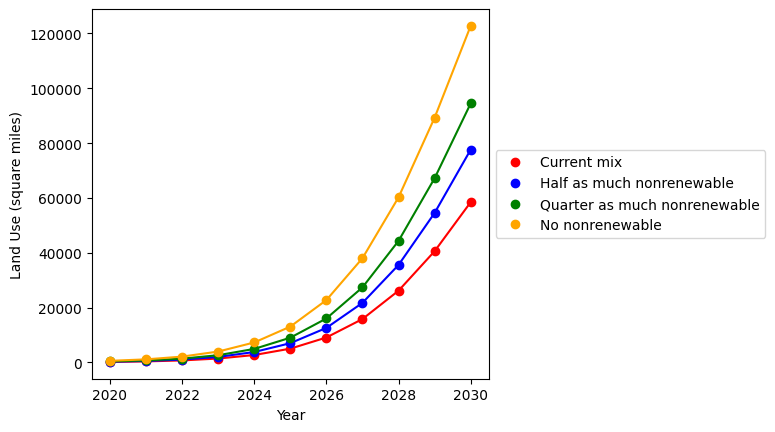

In [161]:


def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : 2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499))), # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206), # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443), # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation

fig,ax = plt.subplots()
years = list(range(2020,2031))
emissions = [(total_land_use(i) / 27878400) for i in years]
print(emissions)
plt.plot(years,emissions ,"o", c="red", label = "Current mix")
plt.plot(years,emissions , c="red")

def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : (2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499)))) * 0.5, # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206) * 0.5, # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443) * 0.5, # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) * 0.5 # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation

years = list(range(2020,2031))
emissions = [(total_land_use(i)/ 27878400) for i in years]
print(emissions)
plt.plot(years,emissions ,"o", c="blue", label = "Half as much nonrenewable")
plt.plot(years,emissions , c="blue")
def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : (2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499)))) * 0.25, # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206) * 0.25, # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443) * 0.25, # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) * 0.25 # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation
years = list(range(2020,2031))
emissions = [(total_land_use(i)/ 27878400) for i in years]
print(emissions)
plt.plot(years,emissions ,"o", c="green", label = "Quarter as much nonrenewable")
plt.plot(years,emissions , c="green")

def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : (2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499)))) * 0, # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206) * 0, # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443) * 0, # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) * 0 # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation

years = list(range(2020,2031))
emissions = [(total_land_use(i)/ 27878400) for i in years]
print(emissions)
plt.plot(years,emissions ,"o", c="orange", label = "No nonrenewable")
plt.plot(years,emissions, c="orange")

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# labels and title
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Land Use (square miles)', fontsize=10)

[197.59303973278003, 385.91991474945496, 747.999401716761, 1435.1611451950355, 2715.7658466547055, 5040.826580980453, 9105.453389051605, 15835.713529057875, 26173.092137983425, 40576.24188292029, 58463.16100761401]
[154.3599370603304, 290.2330789700623, 542.0033854754386, 1002.8723754917094, 1831.9674286012907, 3286.253350520771, 5744.335509498801, 9682.010596952743, 15535.391235507072, 23428.150194972768, 32909.883697503]
[881.936111887106, 1658.2452905067994, 3096.729167773067, 5729.889992007618, 10466.892845954146, 18775.88901762287, 32820.01106927926, 55317.67969826835, 88760.57148448778, 133855.2481387882, 188028.32391950185]
[47.79574983822688, 89.86765404801494, 167.82637695709903, 310.5314114565509, 567.256130100115, 1017.5693386724843, 1778.706260844087, 2997.99845585096, 4810.491098030099, 7254.484334514952, 10190.516190240545]
[1.127985089236721, 2.1214162373252523, 3.962652536998602, 7.333816861843587, 13.399802825462151, 24.04220244926872, 42.03414160564325, 70.86210440293

Text(0, 0.5, 'Land Use (square miles)')

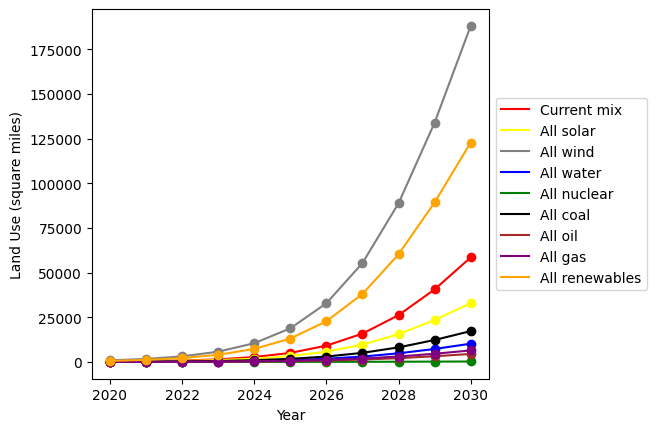

In [162]:


def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : 2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499))), # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206), # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443), # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation
    
fig,ax = plt.subplots()
years = list(range(2020,2031))
emissions = [(total_land_use(i)/ 27878400) for i in years]
print(emissions)
plt.plot(years,emissions , c="red", label = "Current mix")
plt.plot(years,emissions ,"o", c="red")
def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": (0.363898 * math.pow(1.21066, t - 1978.68) - 115.519) * 1, # r^2 0.9996
        "wind" : (1.0399 * math.pow(1.10342, t- 1943.037) - 400.063) * 0, # r^2 0.9991
        "water" : (-5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595) * 0, # r^2 0.9765
        "nuclear" : (2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499)))) * 0, # r^2 0.8343
        "biomass" : (29.0497 * t - 58071.968) *0, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206) * 0, # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443) * 0, # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) * 0 # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation

years = list(range(2020,2031))
emissions = [(total_land_use(i)/ 27878400) for i in years]
print(emissions)
plt.plot(years,emissions , c="yellow", label = "All solar")
plt.plot(years,emissions ,"o", c="yellow")

def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": (0.363898 * math.pow(1.21066, t - 1978.68) - 115.519) * 0, # r^2 0.9996
        "wind" : (1.0399 * math.pow(1.10342, t- 1943.037) - 400.063) * 1, # r^2 0.9991
        "water" : (-5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595) * 0, # r^2 0.9765
        "nuclear" : (2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499)))) * 0, # r^2 0.8343
        "biomass" : (29.0497 * t - 58071.968) *0, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206) * 0, # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443) * 0, # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) * 0 # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation
years = list(range(2020,2031))
emissions = [(total_land_use(i)/ 27878400) for i in years]
print(emissions)
plt.plot(years,emissions , c="gray", label = "All wind")
plt.plot(years,emissions , "o",  c="gray")

def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": (0.363898 * math.pow(1.21066, t - 1978.68) - 115.519) * 0, # r^2 0.9996
        "wind" : (1.0399 * math.pow(1.10342, t- 1943.037) - 400.063) * 0, # r^2 0.9991
        "water" : (-5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595) * 1, # r^2 0.9765
        "nuclear" : (2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499)))) * 0, # r^2 0.8343
        "biomass" : (29.0497 * t - 58071.968) *0, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206) * 0, # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443) * 0, # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) * 0 # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation
years = list(range(2020,2031))
emissions = [(total_land_use(i)/ 27878400) for i in years]
print(emissions)
plt.plot(years,emissions , c="blue", label = "All water")
plt.plot(years,emissions , "o", c="blue")

def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": (0.363898 * math.pow(1.21066, t - 1978.68) - 115.519) * 0, # r^2 0.9996
        "wind" : (1.0399 * math.pow(1.10342, t- 1943.037) - 400.063) * 0, # r^2 0.9991
        "water" : (-5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595) * 0, # r^2 0.9765
        "nuclear" : (2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499)))) * 1, # r^2 0.8343
        "biomass" : (29.0497 * t - 58071.968) *0, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206) * 0, # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443) * 0, # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) * 0 # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation
years = list(range(2020,2031))
emissions = [(total_land_use(i)/ 27878400) for i in years]
print(emissions)
plt.plot(years,emissions , c="green", label = "All nuclear")
plt.plot(years,emissions ,"o", c="green")

def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": (0.363898 * math.pow(1.21066, t - 1978.68) - 115.519) * 0, # r^2 0.9996
        "wind" : (1.0399 * math.pow(1.10342, t- 1943.037) - 400.063) * 0, # r^2 0.9991
        "water" : (-5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595) * 0, # r^2 0.9765
        "nuclear" : (2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499)))) * 0, # r^2 0.8343
        "biomass" : (29.0497 * t - 58071.968) *1, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206) * 0, # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443) * 0, # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) * 0 # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation
years = list(range(2020,2031))
emissions = [(total_land_use(i)/ 27878400) for i in years]
print(emissions)
#plt.plot(years,emissions , c="green", label = "All biomass")
#plt.plot(years,emissions ,"o", c="green")

def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": (0.363898 * math.pow(1.21066, t - 1978.68) - 115.519) * 0, # r^2 0.9996
        "wind" : (1.0399 * math.pow(1.10342, t- 1943.037) - 400.063) * 0, # r^2 0.9991
        "water" : (-5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595) * 0, # r^2 0.9765
        "nuclear" : (2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499)))) * 0, # r^2 0.8343
        "biomass" : (29.0497 * t - 58071.968) *0, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206) * 1, # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443) * 0, # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) * 0 # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation
years = list(range(2020,2031))
emissions = [(total_land_use(i)/ 27878400) for i in years]
print(emissions)
plt.plot(years,emissions , c="black", label = "All coal")
plt.plot(years,emissions ,"o", c="black")

def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": (0.363898 * math.pow(1.21066, t - 1978.68) - 115.519) * 0, # r^2 0.9996
        "wind" : (1.0399 * math.pow(1.10342, t- 1943.037) - 400.063) * 0, # r^2 0.9991
        "water" : (-5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595) * 0, # r^2 0.9765
        "nuclear" : (2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499)))) * 0, # r^2 0.8343
        "biomass" : (29.0497 * t - 58071.968) *0, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206) * 0, # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443) * 1, # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) * 0 # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation
years = list(range(2020,2031))
emissions = [(total_land_use(i)/ 27878400) for i in years]
print(emissions)
plt.plot(years,emissions , c="brown", label = "All oil")
plt.plot(years,emissions ,"o", c="brown")

def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": (0.363898 * math.pow(1.21066, t - 1978.68) - 115.519) * 0, # r^2 0.9996
        "wind" : (1.0399 * math.pow(1.10342, t- 1943.037) - 400.063) * 0, # r^2 0.9991
        "water" : (-5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595) * 0, # r^2 0.9765
        "nuclear" : (2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499)))) * 0, # r^2 0.8343
        "biomass" : (29.0497 * t - 58071.968) *0, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206) * 0, # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443) * 0, # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) * 1 # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation
years = list(range(2020,2031))
emissions = [(total_land_use(i)/ 27878400) for i in years]
print(emissions)
plt.plot(years,emissions , c="purple", label = "All gas")
plt.plot(years,emissions ,"o", c="purple")

def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : (2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499)))) * 0, # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^2 = 0.993
        "coal" : (118.059 * t - 228434.206) * 0, # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443) * 0, # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) * 0 # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation

years = list(range(2020,2031))
emissions = [(total_land_use(i)/ 27878400) for i in years]
print(emissions)
plt.plot(years,emissions , c="orange", label = "All renewables")
plt.plot(years,emissions , "o",c="orange")
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# labels and title
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Land Use (square miles)', fontsize=10)

In [163]:
def total_energy_cost(t):
    return ratio_of_HPC_center(t) * number_of_centers(t) * cost_per_energy(t) * energy_per_center(t)

def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : 2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499))), # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206), # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443), # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation

def cost_per_energy(t):
    energy_mix = {
        "solar": energy_ratio(t, "solar"),
        "wind" : energy_ratio(t, "wind"),
        "water" : energy_ratio(t, "water"),
        "nuclear" : energy_ratio(t, "nuclear"),
        "biomass" : energy_ratio(t, "biomass"),
        "coal" : energy_ratio(t, "coal"),
        "oil" : energy_ratio(t, "oil"),
        "natural gas" : energy_ratio(t, "natural gas")
    }
    summation = 0
    for i in energy_mix.keys():
        summation += energy_mix[i] * (cost_energy_ratios(t)[i])
    return summation

def cost_energy_ratios(t):
    # dollars / kilowatt hour
    return {
        "solar": 0.04,
        "wind" : 0.03,
        "water" : 0.06,
        "nuclear" : 0.082,
        "biomass" : 0.07,
        "coal" : 0.065,
        "oil" : 0.0673,
        "natural gas" : 0.038,
    }


Text(0, 0.5, 'Energy Cost (billions of dollars)')

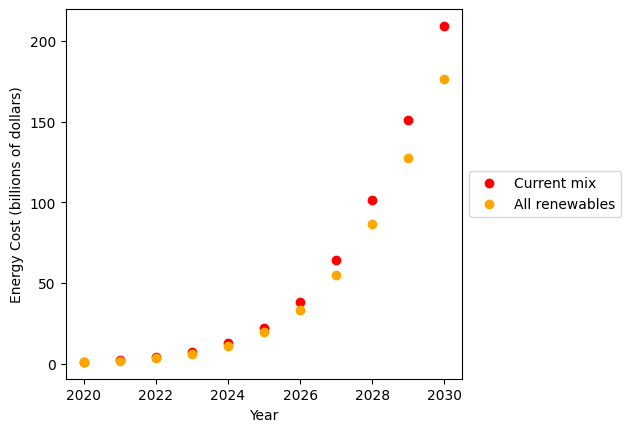

In [164]:
fig,ax = plt.subplots()
years = list(range(2020,2031))
emissions = [(total_energy_cost(i)) for i in years]
emissions = [i / 10**9 for i in emissions]
plt.plot(years,emissions ,"o", c="red", label = "Current mix")

def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : (2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499)))) * 0, # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206) * 0, # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443) * 0, # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245) * 0 # r^2 = 0.9472
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation

years = list(range(2020,2031))
emissions = [(total_energy_cost(i)) for i in years]
emissions = [i / 10**9 for i in emissions]
plt.plot(years,emissions ,"o", c="orange", label = "All renewables")
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# labels and title
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Energy Cost (billions of dollars)', fontsize=10)

Optimization

In [165]:
def optimal_total_carbon_emission(t,solar,wind,water,nuclear,biomass,coal,oil,natural_gas):
    return optimal_total_energy_consumption_carbon(t,solar,wind,water,nuclear,biomass,coal,oil,natural_gas)

def optimal_carbon_energy_ratios(t):
    # g CO2 per kilowatt hour
    return {
        "solar": 52.5,
        "wind" : 11.9,
        "water" : 8.55,
        "nuclear" : 5.65,
        "biomass" : 230,
        "coal" : 1003.5,
        "oil" : 840,
        "natural gas" : 458,
        "geothermal" : 122
    }

def optimal_total_energy_consumption_carbon(t,solar,wind,water,nuclear,biomass,coal,oil,natural_gas):
    return optimal_ratio_of_HPC_center(t) * optimal_energy_per_center(t) * optimal_number_of_centers(t) * optimal_carbon_per_energy(t,solar,wind,water,nuclear,biomass,coal,oil,natural_gas)

def optimal_energy_ratio(t, energy_type,solar,wind,water,nuclear,biomass,coal,oil,natural_gas):
    total_energy_mix = {
        "solar": solar,
        "wind" : wind,
        "water" : water,
        "nuclear" : nuclear,
        "biomass" : biomass,
        "coal" : coal,
        "oil" : oil,
        "natural gas" : natural_gas,
        "geothermal" : 0
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation

def optimal_carbon_per_energy(t,solar,wind,water,nuclear,biomass,coal,oil,natural_gas):
    energy_mix = {
        "solar": optimal_energy_ratio(t, "solar",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "wind" : optimal_energy_ratio(t, "wind",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "water" : optimal_energy_ratio(t, "water",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "nuclear" : optimal_energy_ratio(t, "nuclear",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "biomass" : optimal_energy_ratio(t, "biomass",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "coal" : optimal_energy_ratio(t, "coal",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "oil" : optimal_energy_ratio(t, "oil",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "natural gas" : optimal_energy_ratio(t, "natural gas",solar,wind,water,nuclear,biomass,coal,oil,natural_gas)
    }
    summation = 0
    for i in energy_mix.keys():
        summation += energy_mix[i] * optimal_carbon_energy_ratios(t)[i]
    return summation


def optimal_power_per_hpc_rack():
    # kilowatt hour per year
    return 876000

def optimal_average_power_usage_effectiveness(t):
    return -0.566751 * math.log(0.00461463 * t - 9.26001,10) + 0.9111179

def optimal_ratio_of_HPC_center(t):
    return 1/ (1 + math.pow(math.e, -0.519382 * (t - 2029.669)))
    #return 1
def optimal_number_of_centers(t):
    return 18336.937 / (1 + math.pow(math.e, -0.170416 * (t - 2020.504)))

def optimal_energy_per_center(t):
    return optimal_full_capacity(t) * optimal_average_utilization_rate()

def optimal_average_utilization_rate():
    return 0.61

def optimal_rack_server_per_rack():
    return 21

def optimal_rack_per_center(t):
    return optimal_area_per_building(t) * optimal_rack_space_percentage() / optimal_area_per_rack()

def optimal_area_per_building(t):
    return optimal_total_area(t) / optimal_number_of_centers(t)

def optimal_total_area(t):
    return 560535928.211 / (1 + math.pow(math.e, -0.161079 * (t - 2028.826)))
def optimal_area_per_rack():
    # ft^2
    return 8

def optimal_rack_space_percentage():
    return 0.25

def optimal_carbon_per_server_built():
    # g CO2
    return 1300000

def optimal_carbon_per_building_built(t):
    # g CO2
    return 130640 * optimal_area_per_building(t)

def optimal_full_capacity(t):
    return optimal_rack_per_center(t) * optimal_power_per_hpc_rack() * optimal_average_power_usage_effectiveness(t)


def optimal_total_land_use(t,solar,wind,water,nuclear,biomass,coal,oil,natural_gas):
    return optimal_ratio_of_HPC_center(t) * optimal_number_of_centers(t) * (optimal_area_per_building(t) + optimal_land_per_energy(t,solar,wind,water,nuclear,biomass,coal,oil,natural_gas) * optimal_energy_per_center(t))

def optimal_land_per_energy(t,solar,wind,water,nuclear,biomass,coal,oil,natural_gas):
    energy_mix = {
        "solar": optimal_energy_ratio(t, "solar",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "wind" : optimal_energy_ratio(t, "wind",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "water" : optimal_energy_ratio(t, "water",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "nuclear" : optimal_energy_ratio(t, "nuclear",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "biomass" : optimal_energy_ratio(t, "biomass",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "coal" :optimal_energy_ratio(t, "coal",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "oil" : optimal_energy_ratio(t, "oil",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "natural gas" : optimal_energy_ratio(t, "natural gas",solar,wind,water,nuclear,biomass,coal,oil,natural_gas)
    }
    summation = 0
    for i in energy_mix.keys():
        summation += energy_mix[i] * (optimal_land_energy_ratios(t)[i] * 107639.104 / 10**9)
    return summation

def optimal_land_energy_ratios(t):
    # ha / TWh
    return {
        "solar": 2100,
        "wind" : 12000,
        "water" : 650,
        "nuclear" : 15,
        "biomass" : 58000,
        "coal" : 1100,
        "oil" : 284.431,
        "natural gas" : 410,
        "geothermal" : 75
    }


def optimal_total_energy_cost(t,solar,wind,water,nuclear,biomass,coal,oil,natural_gas):
    return optimal_ratio_of_HPC_center(t) * optimal_number_of_centers(t) * optimal_cost_per_energy(t,solar,wind,water,nuclear,biomass,coal,oil,natural_gas) * optimal_energy_per_center(t)

def optimal_cost_per_energy(t,solar,wind,water,nuclear,biomass,coal,oil,natural_gas):
    energy_mix = {
        "solar": optimal_energy_ratio(t, "solar",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "wind" : optimal_energy_ratio(t, "wind",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "water" : optimal_energy_ratio(t, "water",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "nuclear" : optimal_energy_ratio(t, "nuclear",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "biomass" : optimal_energy_ratio(t, "biomass",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "coal" : optimal_energy_ratio(t, "coal",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "oil" : optimal_energy_ratio(t, "oil",solar,wind,water,nuclear,biomass,coal,oil,natural_gas),
        "natural gas" : optimal_energy_ratio(t, "natural gas",solar,wind,water,nuclear,biomass,coal,oil,natural_gas)
    }
    summation = 0
    for i in energy_mix.keys():
        summation += energy_mix[i] * (optimal_cost_energy_ratios(t)[i])
    return summation

def optimal_cost_energy_ratios(t):
    # dollars / kilowatt hour
    return {
        "solar": 0.04,
        "wind" : 0.03,
        "water" : 0.06,
        "nuclear" : 0.082,
        "biomass" : 0.07,
        "coal" : 0.065,
        "oil" : 0.0673,
        "natural gas" : 0.038,
        "geothermal0" : 0.07
    }

In [166]:
from scipy.optimize import *
def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : 2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499))), # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^3 = 0.993
        "coal" : 118.059 * t - 228434.206, # r^2 = 0.8686
        "oil" : -43.156 * t + 88039.443, # r^2 = 0.9045
        "natural gas" : 153.993 * t - 304728.245, # r^2 = 0.9472
        "geothermal" : 0
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation

def environment_score(vals):
    # Penalize values going below 0 (heavier penalty for negative values)

    # Your existing score calculation
    solar, wind, water, nuclear, biomass, coal, oil, natural_gas = vals
    
    # Adding small epsilon to avoid log of zero
    epsilon = 1e-10
    
    carbon_emission_ratio = total_carbon_emission(2030) / optimal_total_carbon_emission(2030, solar, wind, water, nuclear, biomass, coal, oil, natural_gas)
    land_use_ratio = total_land_use(2030) / optimal_total_land_use(2030, solar, wind, water, nuclear, biomass, coal, oil, natural_gas)
    energy_cost_ratio = total_energy_cost(2030) / optimal_total_energy_cost(2030, solar, wind, water, nuclear, biomass, coal, oil, natural_gas)
    
    # Prevent taking log of zero or negative values by adding epsilon
    return -(0.5 * math.log(max(epsilon, carbon_emission_ratio), math.e) +
             0.3 * math.log(max(epsilon, land_use_ratio), math.e) +
             0.2 * math.log(max(epsilon, energy_cost_ratio), math.e))

# Define bounds for the variables (each energy source should be between 0 and 1)
bounds = Bounds([0] * 8, [0.1,0.1,0.1,0.7,0.1,0.1,0.1,0.1])

# Linear constraint: sum of all variables should equal 1
linear_constraint = LinearConstraint([[1, 1, 1, 1, 1, 1, 1, 1]], [1], [1])

# Initial guess for the optimization, ensuring the sum is 1
x0 = np.array([0.2, 0.1, 0.2, 0.3, 0.1, 0.1, 0, 0])

# Perform optimization with 'trust-constr' which supports constraints
res = minimize(environment_score, x0, method='SLSQP', constraints=[linear_constraint], bounds=bounds)


#print(environment_score([i * 1 for i in res.x]))
print([i * 1 for i in res.x])
print(environment_score(res.x))
print(environment_score([1,0,0,0,0,0,0,0]))
print(environment_score([0,1,0,0,0,0,0,0]))
print(environment_score([0,0,1,0,0,0,0,0]))
print(environment_score([0,0,0,1,0,0,0,0]))
print(environment_score([0,0,0,0,1,0,0,0]))
print(environment_score([0,0,0,0,0,1,0,0]))
print(environment_score([0,0,0,0,0,0,1,0]))
print(environment_score([0,0,0,0,0,0,0,1]))
print(environment_score([0.1684099577524172,0.1296798090169709,0.10296330439818015,0.07087852191495544,0.023229635362208456,0.2900868689032688,0.011183301226306964,0.2035686014256922]))


[0.1, 0.1, 0.1, 0.7, 0.0, 0.0, 0.0, 0.0]
-2.0153817814839705
-1.2543887636118871
-1.5312166883516598
-2.4324313432621905
-3.700418936196809
0.5916666891212274
0.12399213694580952
-0.363451521737574
-0.6714557359758397
-0.0025528749671586666


3.53884057234753


Text(0, 0.5, 'Carbon Dioxide Emissions (billion metric tons)')

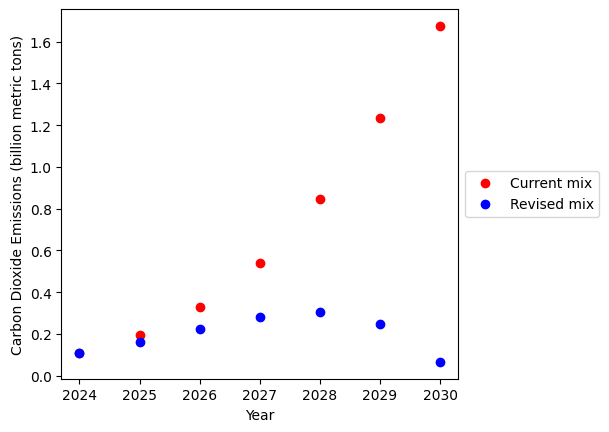

In [167]:

def old_energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : (2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499)))), # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206), # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443), # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245), # r^2 = 0.9472,
        "geothermal" : 0
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation
def new_energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 1.25,
        "wind" : 1.53,
        "water" : 2.43,
        "nuclear" : 3.70,
        "biomass" : 0,
        "coal" : 0,
        "oil" : 0,
        "natural gas" : 0,
        "geothermal" : 0
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation

fig, ax = plt.subplots()
years = list(range(2024,2031))
emissions = [(total_carbon_emission(i) / 10**15) for i in years]
summation = sum(emissions)
plt.plot(years,emissions ,"o", c="red", label = "Current mix")

def energy_ratio(t, energy_type):
    return old_energy_ratio(t,energy_type) + (t-2024) * (new_energy_ratio(t,energy_type) - old_energy_ratio(t,energy_type)) / 6


years = list(range(2024,2031))
emissions = [(total_carbon_emission(i) / 10**15) for i in years]
plt.plot(years,emissions ,"o", c="blue", label = "Revised mix")

print(summation - sum(emissions))

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# labels and title
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Carbon Dioxide Emissions (billion metric tons)', fontsize=10)


58463.16100761401
39783.989319693406
36783.83989548558


Text(0, 0.5, 'Land Use (square miles)')

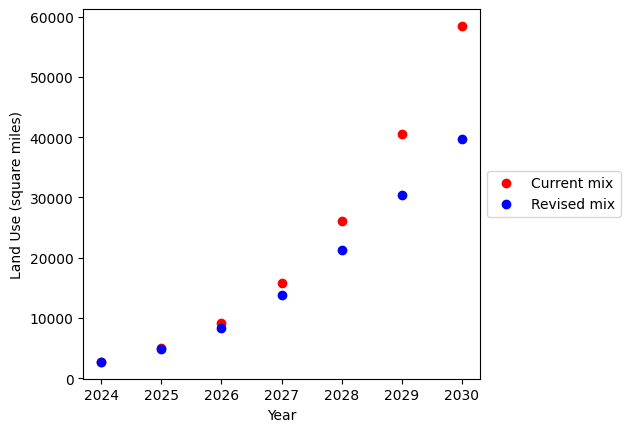

In [168]:
def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : (2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499)))), # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206), # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443), # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245), # r^2 = 0.9472,
        "geothermal" : 0
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation

def old_energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : (2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499)))), # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206), # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443), # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245), # r^2 = 0.9472,
        "geothermal" : 0
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation
def new_energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 1.25,
        "wind" : 1.53,
        "water" : 2.43,
        "nuclear" : 3.70,
        "biomass" : 0,
        "coal" : 0,
        "oil" : 0,
        "natural gas" : 0,
        "geothermal" : 0
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation

fig, ax = plt.subplots()
years = list(range(2024,2031))
emissions = [(total_land_use(i) / 27878400) for i in years]
print(emissions[-1])
summation = sum(emissions)
plt.plot(years,emissions ,"o", c="red", label = "Current mix")

def energy_ratio(t, energy_type):
    return old_energy_ratio(t,energy_type) + (t-2024) * (new_energy_ratio(t,energy_type) - old_energy_ratio(t,energy_type)) / 6


years = list(range(2024,2031))
emissions = [(total_land_use(i) / 27878400) for i in years]
plt.plot(years,emissions ,"o", c="blue", label = "Revised mix")
print(emissions[-1])
print(summation - sum(emissions))

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# labels and title
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Land Use (square miles)', fontsize=10)


209.34512740262056
248.2701368115191
-77.51677853940657


Text(0, 0.5, 'Energy Cost (billions of dollars)')

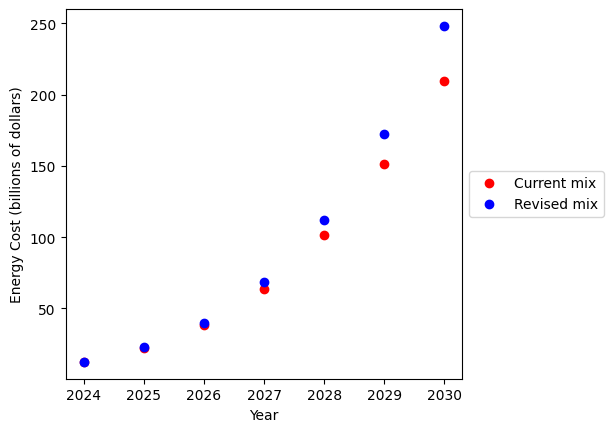

In [169]:
def energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : (2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499)))), # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206), # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443), # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245), # r^2 = 0.9472,
        "geothermal" : 0
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation

def old_energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 0.363898 * math.pow(1.21066, t - 1978.68) - 115.519, # r^2 0.9996
        "wind" : 1.0399 * math.pow(1.10342, t- 1943.037) - 400.063, # r^2 0.9991
        "water" : -5.552287 * math.pow(t, 2) + 22460.883 * t - 22711188.595, # r^2 0.9765
        "nuclear" : (2752.692 / (1 + math.pow(math.e, 0 - (0.20548 * t - 411.499)))), # r^2 0.8343
        "biomass" : 29.0497 * t - 58071.968, # r^3 = 0.993
        "coal" : (118.059 * t - 228434.206), # r^2 = 0.8686
        "oil" : (-43.156 * t + 88039.443), # r^2 = 0.9045
        "natural gas" : (153.993 * t - 304728.245), # r^2 = 0.9472,
        "geothermal" : 0
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation
def new_energy_ratio(t, energy_type):
    total_energy_mix = {
        "solar": 1.25,
        "wind" : 1.53,
        "water" : 2.43,
        "nuclear" : 3.70,
        "biomass" : 0,
        "coal" : 0,
        "oil" : 0,
        "natural gas" : 0,
        "geothermal" : 0
    }
    total_energy_generation = sum(total_energy_mix.values())
    return total_energy_mix[energy_type] / total_energy_generation

fig, ax = plt.subplots()
years = list(range(2024,2031))
emissions = [(total_energy_cost(i) / 10**9) for i in years]
print(emissions[-1])
summation = sum(emissions)
plt.plot(years,emissions ,"o", c="red", label = "Current mix")

def energy_ratio(t, energy_type):
    return old_energy_ratio(t,energy_type) + (t-2024) * (new_energy_ratio(t,energy_type) - old_energy_ratio(t,energy_type)) / 6


years = list(range(2024,2031))
emissions = [(total_energy_cost(i) / 10**9) for i in years]
plt.plot(years,emissions ,"o", c="blue", label = "Revised mix")
print(emissions[-1])
print(summation - sum(emissions))

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# labels and title
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Energy Cost (billions of dollars)', fontsize=10)


Text(0.5, 1.0, 'Energy proportions of energy types')

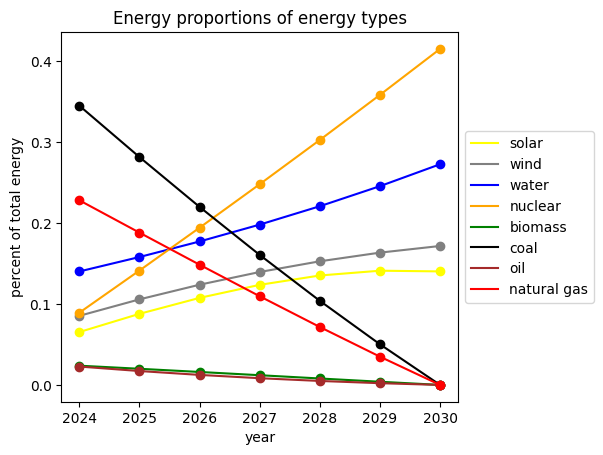

In [170]:
fig,ax = plt.subplots()
years = list(range(2024,2031))

energy_types = ["solar","wind","water","nuclear","biomass","coal","oil","natural gas"]
color = {
    "solar" : "yellow",
    "wind" : "gray",
    "water" : "blue",
    "nuclear" : "orange",
    "biomass" : "green",
    "coal" : "black",
    "oil" : "brown",
    "natural gas" : "red"
}
nonrenewable2024 = 0
nonrenewable2030 = 0
for e in energy_types:
    percentiles = [energy_ratio(i,e) for i in years]
    plt.plot(years, percentiles , c=color[e], label = e)
    plt.plot(years, percentiles , 'o' ,c=color[e])
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])


# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# labels and title
ax.set_xlabel('year', fontsize=10)
ax.set_ylabel('percent of total energy', fontsize=10)
ax.set_title('Energy proportions of energy types')
